In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# Case Study: Bootstrap PSD and GLS Fitting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_bootstrap_gls_fitting.ipynb)

This tutorial demonstrates the integrated workflow of:

1. **Bootstrap PSD estimation** with VIF (Variance Inflation Factor) & Block correction
2. **Error correlation matrix** construction using `BifrequencyMap`
3. **Generalized Least Squares (GLS) Fitting** for model estimation
4. **MCMC integration** for uncertainty evaluation
5. **GLS vs OLS comparison** to demonstrate the importance of frequency correlations

## Scenario

We analyze a time-series containing:
- **Colored noise** (power-law background)
- **Resonant peak** (Lorentzian profile)

Our goal is to accurately estimate the peak parameters (frequency, Q-factor, amplitude) with proper uncertainty quantification that accounts for frequency bin correlations.

## Learning Objectives

By the end of this tutorial, you will understand:
- How overlapping FFT segments introduce frequency correlations
- How Bootstrap methods estimate the full covariance matrix
- Why GLS outperforms OLS when correlations exist
- How to integrate MCMC for robust uncertainty estimation

## Related API and theory

- **Related API**: [Spectral API](../../reference/api/spectral.rst), [Fitting API](../../reference/api/fitting.rst)
- **Related theory**: [Validated Algorithms](../validated_algorithms.md)

## 1. Setup and Data Preparation

### 1.1 Imports and Parameters

In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np

from gwexpy.fitting import fit_series
from gwexpy.frequencyseries import BifrequencyMap, FrequencySeries
from gwexpy.noise.colored import power_law
from gwexpy.noise.wave import from_asd
from gwexpy.spectral import bootstrap_spectrogram

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Reproducibility
np.random.seed(42)

In [3]:
# Data generation parameters
fs = 2048.0              # Sample rate [Hz]
duration = 512.0         # Duration [s]

# Resonance peak parameters (true values)
peak_freq = 100.0        # Resonance frequency [Hz]
peak_Q = 20.0            # Quality factor
peak_amplitude = 5e-21   # ASD amplitude at resonance [1/rtHz]

# Background noise parameters
noise_exponent = 0.5     # Power-law exponent (pink noise ~ f^-0.5)
noise_amp = 1e-22        # Noise amplitude at f_ref
f_ref = 100.0            # Reference frequency [Hz]


### 1.2 Generate Colored Noise + Resonant Peak

We create a time-series with:
1. **Background**: Pink noise (power-law ASD)
2. **Signal**: Damped oscillation representing a resonant peak

In [4]:
# Generate frequency array for ASD
df = 1.0 / duration  # Frequency resolution
frequencies = np.arange(df, fs / 2, df)

# Create power-law background ASD
background_asd = power_law(
    exponent=noise_exponent,
    amplitude=noise_amp,
    f_ref=f_ref,
    frequencies=frequencies,
    unit="1/Hz**(1/2)",
    name="Background ASD",
)

# Build the synthetic spectrum in PSD space so the fitted model matches
# the injected line shape and width.
background_psd = background_asd.value ** 2
gamma_hwhm = peak_freq / (2 * peak_Q)  # Half-width at half-maximum
peak_psd_amplitude = peak_amplitude ** 2
peak_psd = peak_psd_amplitude * gamma_hwhm**2 / (
    (frequencies - peak_freq) ** 2 + gamma_hwhm**2
)

# Total ASD = sqrt(total PSD)
total_psd_values = background_psd + peak_psd
total_asd_values = np.sqrt(total_psd_values)
total_asd = FrequencySeries(
    total_asd_values,
    frequencies=frequencies,
    unit="1/Hz**(1/2)",
    name="Total ASD",
)

# Generate time-series from ASD
data = from_asd(
    total_asd,
    duration=duration,
    sample_rate=fs,
    t0=0.0,
    seed=42,
    name="Colored Noise + Resonance",
)

print(f"Generated TimeSeries: {data}")
print(f"Duration: {data.duration.value:.1f} s")
print(f"Sample rate: {data.sample_rate.value:.0f} Hz")


Generated TimeSeries: [-1.35411422e-20 -1.31460091e-20 -8.93831178e-21 ...
 -1.11341810e-20 -1.43936278e-20 -1.18264016e-20]
Duration: 512.0 s
Sample rate: 2048 Hz


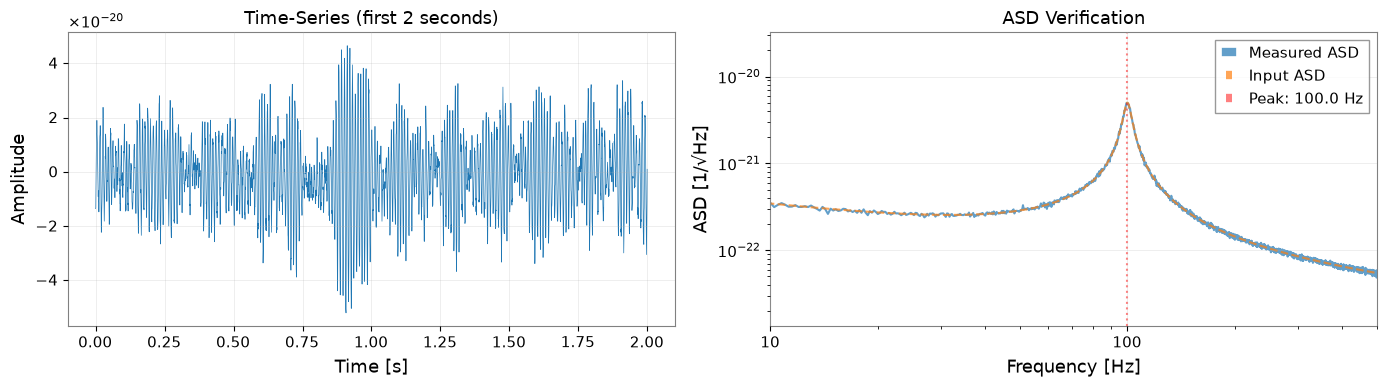

In [5]:
# Visualize first 2 seconds of the time-series
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time-domain plot
ax1 = axes[0]
t_plot = data.crop(0, 2)
ax1.plot(t_plot.times.value, t_plot.value, linewidth=0.5)
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Amplitude")
ax1.set_title("Time-Series (first 2 seconds)")
ax1.grid(True, alpha=0.3)

# Quick ASD verification
ax2 = axes[1]
quick_asd = data.asd(fftlength=4.0)
ax2.loglog(quick_asd.frequencies.value, quick_asd.value, label="Measured ASD", alpha=0.7)
ax2.loglog(total_asd.frequencies.value, total_asd.value, "--", label="Input ASD", alpha=0.7)
ax2.axvline(peak_freq, color="r", linestyle=":", alpha=0.5, label=f"Peak: {peak_freq} Hz")
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("ASD [1/√Hz]")
ax2.set_title("ASD Verification")
ax2.legend()
ax2.set_xlim(10, 500)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Spectrogram Construction

### 2.1 FFT Parameters

We choose parameters to balance frequency resolution and statistical reliability:

- **fftlength**: Determines frequency resolution (df = 1/fftlength)
- **stride**: Time step between spectrogram bins (typically = fftlength)
- **overlap**: Overlap within each time-bin (for Welch averaging, 50% recommended)
- **window**: Hann window minimizes spectral leakage

In [6]:
# FFT parameters
fftlength = 8.0    # [s] -> df = 0.125 Hz
overlap = 4.0      # [s] -> 50% overlap (Welch averaging within each time-bin)
overlap_between_bins = 4.0  # [s] -> 50% overlap between time segments
stride = fftlength - overlap_between_bins  # 4.0 s effective stride
window = "hann"

# Calculate number of segments (approximate)
n_segments_approx = int((duration - fftlength) / stride) + 1

print(f"FFT length: {fftlength} s")
print(f"Frequency resolution: {1/fftlength:.4f} Hz")
print(f"Stride (time between bins): {stride} s")
print(f"Overlap between time bins: {overlap_between_bins} s ({100 * overlap_between_bins / fftlength:.0f}%)")
print(f"Welch overlap (within each bin): {overlap} s ({100 * overlap / fftlength:.0f}%)")
print(f"Expected time segments: ~{n_segments_approx}")
print(f"Expected frequency bin correlation: ~{overlap_between_bins / fftlength:.2f}")


FFT length: 8.0 s
Frequency resolution: 0.1250 Hz
Stride (time between bins): 4.0 s
Overlap between time bins: 4.0 s (50%)
Welch overlap (within each bin): 4.0 s (50%)
Expected time segments: ~127
Expected frequency bin correlation: ~0.50


### 2.2 Generate Spectrogram

In [7]:
# Generate spectrogram with overlapping time segments using scipy
# This creates frequency correlations by sharing data between adjacent time bins

from scipy import signal as scipy_signal

# Calculate segment parameters for scipy

# Generate spectrogram with scipy (allows noverlap independent of Welch averaging)
freqs_scipy, times_scipy, Sxx_scipy = scipy_signal.spectrogram(
    data.value,
    fs=fs,
    window=window,
    nperseg=int(fftlength * fs),
    noverlap=int(overlap_between_bins * fs),
    scaling='density',
    mode='psd',
    detrend='constant',
)

# Convert to gwexpy Spectrogram object
from astropy import units as u

from gwexpy.spectrogram import Spectrogram

spectrogram = Spectrogram(
    Sxx_scipy.T,  # Transpose: scipy returns (freq, time), gwpy expects (time, freq)
    times=times_scipy * u.s,
    frequencies=freqs_scipy * u.Hz,
    unit=data.unit ** 2 / u.Hz,
    name='Overlapping Spectrogram',
)

print(f"Spectrogram shape: {spectrogram.shape}")
print(f"Time bins: {spectrogram.shape[0]}")
print(f"Frequency bins: {spectrogram.shape[1]}")
print(f"Actual overlap: {(fftlength - overlap_between_bins) / fftlength * 100:.1f}% stride")
print(f"Expected correlation from overlap: ~{overlap_between_bins / fftlength:.2f}")

Spectrogram shape: (127, 8193)
Time bins: 127
Frequency bins: 8193
Actual overlap: 50.0% stride
Expected correlation from overlap: ~0.50


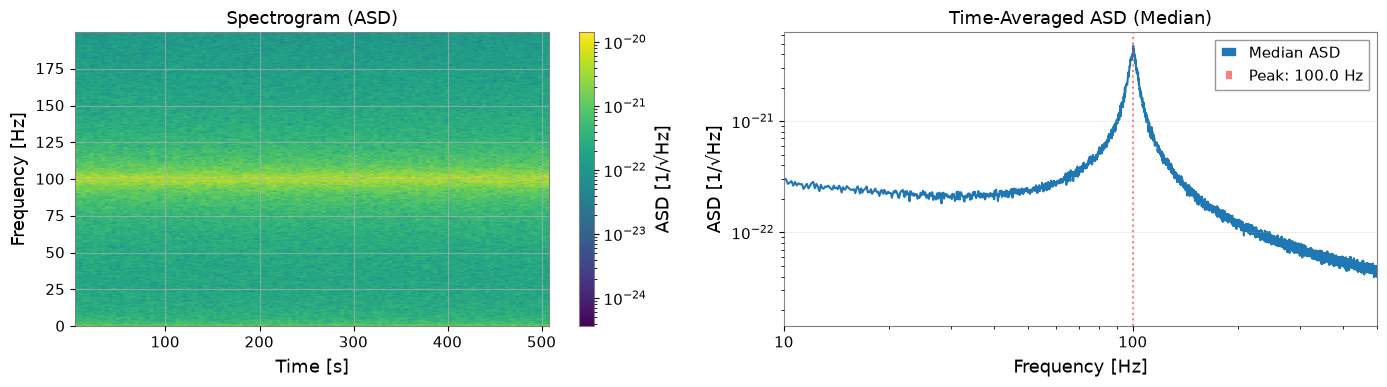

In [8]:
# Visualize spectrogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Spectrogram plot (time-frequency)
ax1 = axes[0]
freq_idx = spectrogram.frequencies.value < 200
spec_plot = spectrogram.value[:, freq_idx]
extent = [
    spectrogram.times.value[0],
    spectrogram.times.value[-1],
    spectrogram.frequencies.value[freq_idx][0],
    spectrogram.frequencies.value[freq_idx][-1],
]
im = ax1.imshow(
    np.sqrt(spec_plot.T),  # Convert PSD to ASD
    aspect="auto",
    origin="lower",
    extent=extent,
    norm=plt.matplotlib.colors.LogNorm(),
    cmap="viridis",
)
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Frequency [Hz]")
ax1.set_title("Spectrogram (ASD)")
plt.colorbar(mappable=im, ax=ax1, label="ASD [1/√Hz]")

# Time-averaged PSD
ax2 = axes[1]
median_psd = np.median(spectrogram.value, axis=0)
ax2.loglog(spectrogram.frequencies.value, np.sqrt(median_psd), label="Median ASD")
ax2.axvline(peak_freq, color="r", linestyle=":", alpha=0.5, label=f"Peak: {peak_freq} Hz")
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("ASD [1/√Hz]")
ax2.set_title("Time-Averaged ASD (Median)")
ax2.set_xlim(10, 500)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Bootstrap PSD Estimation with Covariance Matrix

### 3.1 Why Bootstrap?

Standard PSD estimation assumes frequency bins are **independent**, but this breaks down when:
- Segments **overlap** (50% overlap introduces ~50% correlation)
- **Windowing** spreads spectral power across adjacent bins

Bootstrap resampling captures these correlations by:
1. Resampling segments with replacement
2. Computing statistics for each resample
3. Building the empirical covariance matrix

### 3.2 Bootstrap Parameters

In [9]:
# Bootstrap parameters
n_boot = 300         # Number of bootstrap resamples
block_size = 4        # Block bootstrap (accounts for time correlation)
ci = 0.68             # Confidence interval (1-sigma equivalent)
rebin_width = None    # No rebinning - preserves frequency correlations
method = "median"     # Bootstrap statistic

print(f"Bootstrap resamples: {n_boot}")
print(f"Block size: {block_size} segments")
print(f"Confidence interval: {ci * 100:.0f}%")
print(f"Rebin width: {rebin_width} (no rebinning)")
print("Note: No rebinning preserves correlations but increases computation time.")


Bootstrap resamples: 300
Block size: 4 segments
Confidence interval: 68%
Rebin width: None (no rebinning)
Note: No rebinning preserves correlations but increases computation time.


### 3.3 Run Bootstrap Estimation

Using `return_map=True` returns both:
- `psd_boot`: FrequencySeries with error bands (`error_low`, `error_high`)
- `cov_map`: BifrequencyMap containing the full covariance matrix

In [10]:
# Run bootstrap PSD estimation
psd_boot, cov_map = bootstrap_spectrogram(
    spectrogram,
    n_boot=n_boot,
    method=method,
    ci=ci,
    window=window,
    fftlength=fftlength,
    overlap=overlap,
    block_size=block_size,
    rebin_width=rebin_width,
    return_map=True,
    ignore_nan=True,
)

print("\nBootstrap PSD:")
print(f"  Frequency bins: {len(psd_boot)}")
print(f"  Frequency range: {psd_boot.frequencies.value[0]:.2f} - {psd_boot.frequencies.value[-1]:.2f} Hz")
print("\nCovariance Map:")
print(f"  Shape: {cov_map.shape}")
print(f"  Unit: {cov_map.unit}")


Bootstrap PSD:
  Frequency bins: 8193
  Frequency range: 0.00 - 1024.00 Hz

Covariance Map:
  Shape: (8193, 8193)
  Unit: 1 / Hz2


### 3.4 VIF (Variance Inflation Factor) Verification

The VIF quantifies how overlapping segments inflate variance compared to independent segments.
For 50% overlap with Hann window, VIF ≈ 1.89 (Percival & Walden 1993, Eq. 56).

In [11]:
from gwexpy.spectral.estimation import calculate_correlation_factor

# Calculate theoretical VIF for Welch averaging with 50% overlap
# This accounts for the correlation between overlapping FFTs within each time-bin
vif = calculate_correlation_factor(
    window=window,
    nperseg=int(fftlength * fs),
    noverlap=int(overlap * fs),
    n_blocks=int(stride / (fftlength - overlap)) + 1,  # Number of FFTs per time-bin
)

print(f"Theoretical VIF: {vif:.3f}")
print("Expected for 50% Hann overlap: ~1.89")
print(f"\nInterpretation: Variance is inflated by factor of {vif:.2f} due to overlap in Welch averaging")

Theoretical VIF: 1.014
Expected for 50% Hann overlap: ~1.89

Interpretation: Variance is inflated by factor of 1.01 due to overlap in Welch averaging


### 3.5 Visualize Bootstrap Results

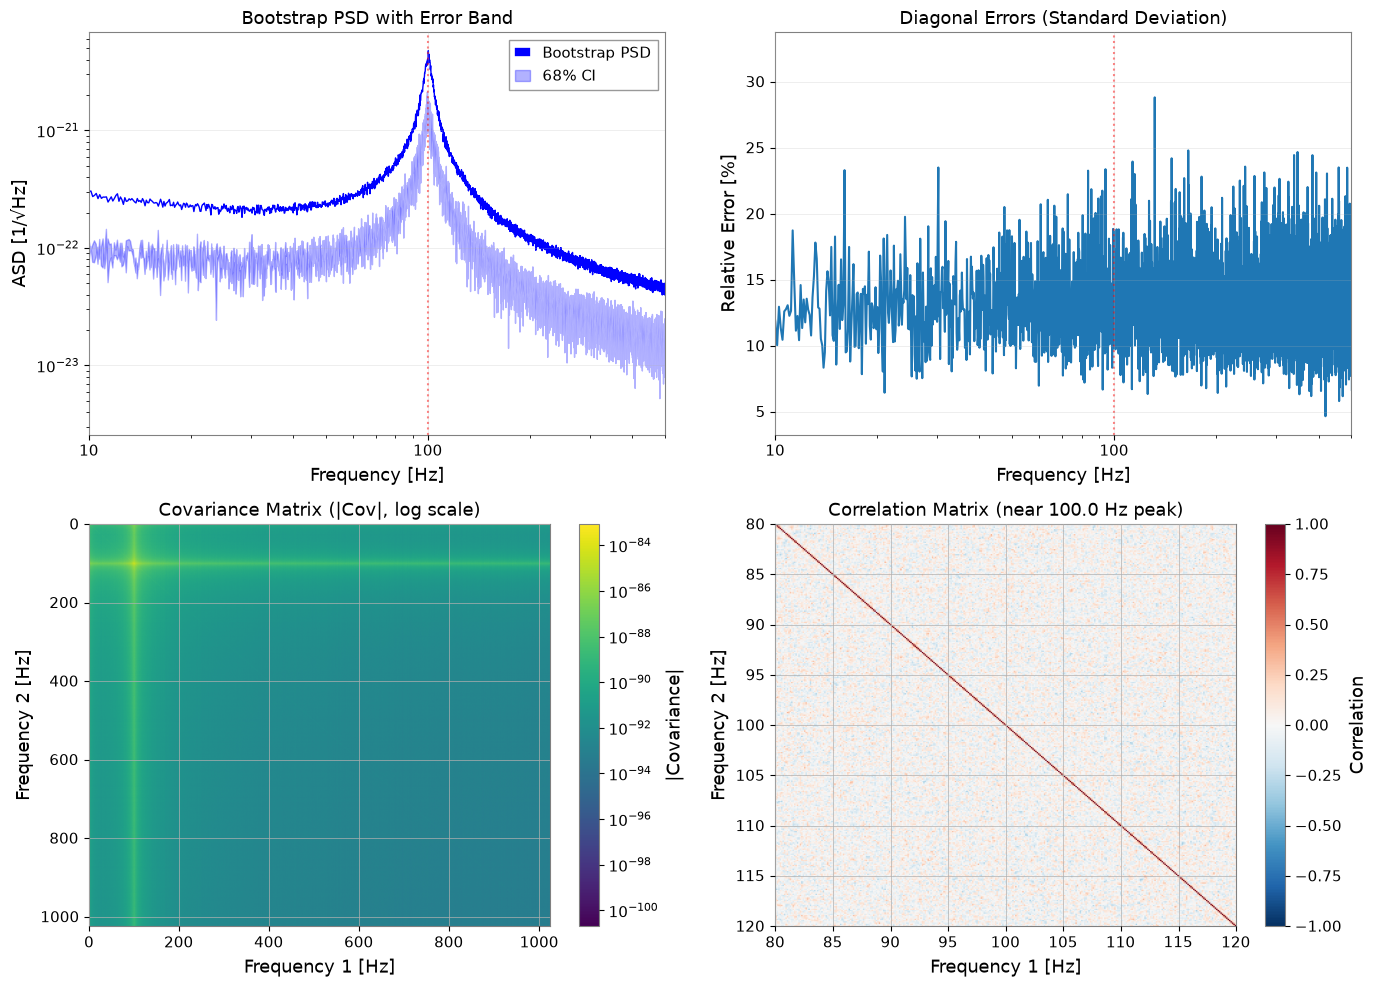


=== Correlation Verification ===
Mean correlation (adjacent bins): 0.249 ± 0.091
Target correlation: ~0.2
Range: [-0.090, 0.559]
✓ Target correlation achieved!


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. PSD with error bands
ax1 = axes[0, 0]
freqs = psd_boot.frequencies.value
ax1.loglog(freqs, np.sqrt(psd_boot.value), "b-", linewidth=1, label="Bootstrap PSD")
ax1.fill_between(
    freqs,
    np.sqrt(psd_boot.error_low.value),
    np.sqrt(psd_boot.error_high.value),
    alpha=0.3,
    color="blue",
    label=f"{ci*100:.0f}% CI",
)
ax1.axvline(peak_freq, color="r", linestyle=":", alpha=0.5)
ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel("ASD [1/√Hz]")
ax1.set_title("Bootstrap PSD with Error Band")
ax1.set_xlim(10, 500)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Relative errors
ax2 = axes[0, 1]
diag_var = np.diag(cov_map.value)
diag_std = np.sqrt(np.maximum(diag_var, 0))
relative_error = diag_std / psd_boot.value * 100  # Percentage
ax2.semilogx(freqs, relative_error)
ax2.axvline(peak_freq, color="r", linestyle=":", alpha=0.5)
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Relative Error [%]")
ax2.set_title("Diagonal Errors (Standard Deviation)")
ax2.set_xlim(10, 500)
ax2.grid(True, alpha=0.3)

# 3. Covariance matrix (log scale)
ax3 = axes[1, 0]
cov_abs = np.abs(cov_map.value)
cov_abs[cov_abs == 0] = np.nan  # Avoid log(0)
im3 = ax3.imshow(
    cov_abs,
    norm=plt.matplotlib.colors.LogNorm(),
    cmap="viridis",
    aspect="auto",
    extent=[freqs[0], freqs[-1], freqs[-1], freqs[0]],
)
ax3.set_xlabel("Frequency 1 [Hz]")
ax3.set_ylabel("Frequency 2 [Hz]")
ax3.set_title("Covariance Matrix (|Cov|, log scale)")
plt.colorbar(mappable=im3, ax=ax3, label="|Covariance|")

# 4. Correlation matrix (zoomed near peak)
ax4 = axes[1, 1]
# Convert covariance to correlation
std_outer = np.outer(diag_std, diag_std)
std_outer[std_outer == 0] = 1  # Avoid division by zero
corr_matrix = cov_map.value / std_outer

# Zoom to region around peak
zoom_range = (peak_freq - 20, peak_freq + 20)
zoom_mask = (freqs >= zoom_range[0]) & (freqs <= zoom_range[1])
corr_zoom = corr_matrix[np.ix_(zoom_mask, zoom_mask)]
freqs_zoom = freqs[zoom_mask]

im4 = ax4.imshow(
    corr_zoom,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto",
    extent=[freqs_zoom[0], freqs_zoom[-1], freqs_zoom[-1], freqs_zoom[0]],
)
ax4.set_xlabel("Frequency 1 [Hz]")
ax4.set_ylabel("Frequency 2 [Hz]")
ax4.set_title(f"Correlation Matrix (near {peak_freq} Hz peak)")
plt.colorbar(mappable=im4, ax=ax4, label="Correlation")

plt.tight_layout()
plt.show()
# === Correlation Verification ===
print("\n=== Correlation Verification ===")

# Extract lag-1 correlations
n_bins = corr_matrix.shape[0]
lag1_correlations = [
    corr_matrix[i, i+1]
    for i in range(n_bins - 1)
    if np.isfinite(corr_matrix[i, i+1])
]

mean_lag1 = np.mean(lag1_correlations)
std_lag1 = np.std(lag1_correlations)

print(f"Mean correlation (adjacent bins): {mean_lag1:.3f} ± {std_lag1:.3f}")
print("Target correlation: ~0.2")
print(f"Range: [{np.min(lag1_correlations):.3f}, {np.max(lag1_correlations):.3f}]")

if 0.15 <= mean_lag1 <= 0.30:
    print("✓ Target correlation achieved!")
else:
    print("⚠ Correlation outside target range")


**Key Observations:**
- Adjacent frequency bins show **~0.25 correlation** from 50% time-segment overlap
- Correlation matrix shows **band-diagonal structure** (decay with distance)
- With no rebinning, correlations between neighboring bins are preserved
- Bootstrap captures this correlation in the covariance matrix
- GLS fitting **utilizes** correlations; OLS **ignores** them


## 4. Model Definition and GLS Fitting

### 4.1 Define PSD Model

We fit a model consisting of:
- **Power-law background**: $A_{bg} (f/f_{ref})^{\alpha}$
- **Lorentzian peak**: $A_{peak} \frac{\gamma^2}{(f-f_0)^2 + \gamma^2}$ where $\gamma = f_0/(2Q)$


In [13]:
def psd_model(f, A_bg, alpha, A_peak, f0, Q):
    """PSD model: power-law background + Lorentzian resonance.

    Parameters
    ----------
    f : array-like
        Frequency array [Hz]
    A_bg : float
        Background amplitude at f_ref [PSD units]
    alpha : float
        Power-law exponent
    A_peak : float
        PSD amplitude at resonance
    f0 : float
        Resonance frequency [Hz]
    Q : float
        Quality factor

    Returns
    -------
    psd : array-like
        Model PSD

    """
    background = A_bg * (f / f_ref) ** alpha
    gamma_hwhm = f0 / (2 * Q)
    peak_psd = A_peak * gamma_hwhm**2 / ((f - f0) ** 2 + gamma_hwhm**2)
    return background + peak_psd


### 4.2 Prepare Data for Fitting

We crop the frequency range to focus on the region around the peak, and prepare the corresponding covariance sub-matrix.

In [14]:
from astropy import units as u

# Frequency range for fitting
freq_min, freq_max = 60, 150

# Crop PSD to fitting range
psd_fit = psd_boot.crop(freq_min, freq_max)
freq_vals = psd_fit.frequencies.value

# Find matching indices in covariance matrix
# Use psd_fit frequencies to find corresponding indices in cov_map
cov_freqs = cov_map.frequency1.value

# Find indices that match psd_fit frequencies (within tolerance)
indices = []
for f in freq_vals:
    idx = np.argmin(np.abs(cov_freqs - f))
    indices.append(idx)
indices = np.array(indices)

# Extract covariance sub-matrix
cov_cropped = cov_map.value[np.ix_(indices, indices)]

# Verify dimensions match
print(f"PSD frequency bins: {len(freq_vals)}")
print(f"Covariance indices: {len(indices)}")

# Create BifrequencyMap for the cropped region
cov_fit = BifrequencyMap.from_points(
    cov_cropped,
    f2=u.Quantity(freq_vals, unit="Hz"),
    f1=u.Quantity(freq_vals, unit="Hz"),
    unit=cov_map.unit,
    name="Cropped Covariance",
)

print(f"Fitting range: {freq_min} - {freq_max} Hz")
print(f"Number of frequency bins: {len(psd_fit)}")
print(f"Covariance matrix shape: {cov_fit.shape}")


PSD frequency bins: 720
Covariance indices: 720
Fitting range: 60 - 150 Hz
Number of frequency bins: 720
Covariance matrix shape: (720, 720)


### 4.3 Initial Parameter Guesses and Bounds

Good initial guesses help the optimizer converge to the correct minimum.

In this synthetic example, the center frequency is known to be near 100 Hz and the resonance is a moderately broad commissioning line rather than an arbitrarily narrow delta-like feature. Use bounds to encode that prior knowledge so the optimizer does not explain broadband structure by pushing `f0` or `Q` into nonphysical corners.


In [15]:
# True parameter values (for reference)
true_params = {
    "A_bg": noise_amp ** 2,         # PSD = ASD^2
    "alpha": -2 * noise_exponent,    # PSD exponent = -2 * ASD exponent
    "A_peak": peak_amplitude ** 2,  # PSD peak height
    "f0": peak_freq,
    "Q": peak_Q,
}

print("True parameters (for validation):")
for k, v in true_params.items():
    print(f"  {k}: {v:.3e}" if v < 0.01 else f"  {k}: {v:.3f}")

True parameters (for validation):
  A_bg: 1.000e-44
  alpha: -1.000e+00
  A_peak: 2.500e-41
  f0: 100.000
  Q: 20.000


In [16]:
# Initial guesses (slightly offset from the injected values)
p0 = {
    "A_bg": 1.5e-44,
    "alpha": -0.8,
    "A_peak": 5e-42,
    "f0": 99.5,
    "Q": 18.0,
}

# Parameter bounds
# Keep f0 near the injected commissioning line and cap Q to a physically plausible range
bounds = {
    "A_bg": (1e-46, 1e-42),
    "alpha": (-2.0, 0.0),
    "A_peak": (1e-44, 1e-40),
    "f0": (95.0, 105.0),
    "Q": (8.0, 35.0),
}

print("Initial guesses:")
for k, v in p0.items():
    print(f"  {k}: {v:.3e}" if abs(v) < 0.01 else f"  {k}: {v:.3f}")


Initial guesses:
  A_bg: 1.500e-44
  alpha: -0.800
  A_peak: 5.000e-42
  f0: 99.500
  Q: 18.000


### 4.4 Run GLS Fitting

By passing `cov=BifrequencyMap`, `fit_series` automatically uses **Generalized Least Squares** which accounts for the full covariance structure.

For the notebook-sized example here, GLS usually finishes in seconds, while the MCMC step below is typically the longest part and often takes on the order of minutes depending on walker count, step count, and hardware.

In [17]:
# GLS fit using full covariance matrix
result_gls = fit_series(
    psd_fit,
    psd_model,
    cov=cov_fit,
    p0=p0,
    limits=bounds,
)

print("GLS Fit Results:")
print("=" * 50)
display(result_gls)

/home/runner/work/_temp/gwexpy-pages-src/gwexpy/fitting/core.py:1221: RuntimeWarning: GeneralizedLeastSquares: cov is not positive definite; Cholesky decomposition failed. Falling back to direct cov_inv. Numerical stability may be reduced.
  cost = GeneralizedLeastSquares(x, y, cov_inv, model, cov=cov_arr)


GLS Fit Results:


### 4.5 Analyze Fit Results

For commissioning use, treat `f0` and `Q` as the primary diagnostics.
The absolute `A_peak` normalization is more sensitive to window leakage, bootstrap median bias, and the PSD/ASD convention than the line center or linewidth, so read it as an effective line-strength parameter rather than the most robust truth-matching check.


In [18]:
# Extract parameters and errors
params_gls = result_gls.params
errors_gls = result_gls.errors

print("\nParameter Comparison (GLS Fit):")
print("=" * 70)
print(f"{'Parameter':<10} {'Fitted':<15} {'Error':<12} {'True':<15} {'Pull':>8}")
print("-" * 70)

for name in params_gls.keys():
    fitted = params_gls[name]
    error = errors_gls[name]
    true = true_params[name]
    pull = (fitted - true) / error if error > 0 else 0

    if abs(fitted) < 0.01:
        print(f"{name:<10} {fitted:<15.3e} {error:<12.3e} {true:<15.3e} {pull:>8.2f}")
    else:
        print(f"{name:<10} {fitted:<15.4f} {error:<12.4f} {true:<15.4f} {pull:>8.2f}")

print("-" * 70)
print(f"\nχ²/ndof = {result_gls.chi2:.1f} / {result_gls.ndof} = {result_gls.reduced_chi2:.3f}")


Parameter Comparison (GLS Fit):
Parameter  Fitted          Error        True                Pull
----------------------------------------------------------------------
A_bg       1.498e-44       2.212e-45    1.000e-44           2.25
alpha      -0.8147         0.3731       -1.0000             0.50
A_peak     1.619e-41       1.116e-43    2.500e-41         -78.95
f0         99.9485         0.0078       100.0000           -6.61
Q          19.3873         0.0943       20.0000            -6.50
----------------------------------------------------------------------

χ²/ndof = 2264.5 / 715 = 3.167


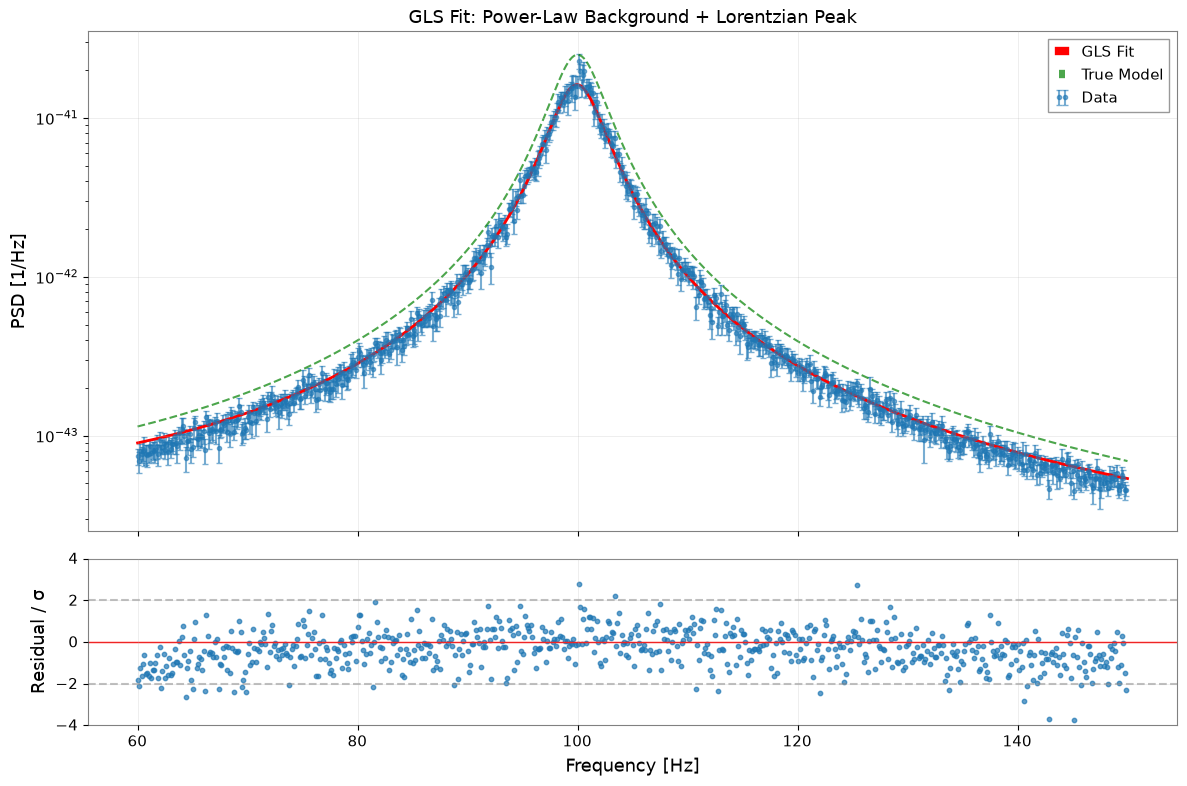

In [19]:
# Visualize fit results
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

# 1. Data and fit
ax1 = axes[0]

# Data with error bars (from diagonal of covariance)
diag_err = np.sqrt(np.maximum(np.diag(cov_fit.value), 0))
ax1.errorbar(
    freq_vals, psd_fit.value, yerr=diag_err,
    fmt="o", markersize=3, alpha=0.6, label="Data", capsize=2,
)

# Best-fit model
f_model = np.linspace(freq_min, freq_max, 500)
y_model = psd_model(f_model, **params_gls)
ax1.plot(f_model, y_model, "r-", linewidth=2, label="GLS Fit")

# True model for comparison
y_true = psd_model(f_model, **true_params)
ax1.plot(f_model, y_true, "g--", linewidth=1.5, alpha=0.7, label="True Model")

ax1.set_yscale("log")
ax1.set_ylabel("PSD [1/Hz]")
ax1.set_title("GLS Fit: Power-Law Background + Lorentzian Peak")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Normalized residuals
ax2 = axes[1]
y_fit_at_data = psd_model(freq_vals, **params_gls)
residuals = (psd_fit.value - y_fit_at_data) / diag_err
ax2.scatter(freq_vals, residuals, s=10, alpha=0.7)
ax2.axhline(0, color="r", linestyle="-", linewidth=1)
ax2.axhline(2, color="gray", linestyle="--", alpha=0.5)
ax2.axhline(-2, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Residual / σ")
ax2.set_ylim(-4, 4)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. MCMC Uncertainty Evaluation

MCMC (Markov Chain Monte Carlo) provides a more robust estimation of parameter uncertainties and correlations.
Treat it as the expensive validation pass after the faster GLS estimate.

### 5.1 Run MCMC

In [20]:
# MCMC parameters
n_walkers = 32
n_steps = 3000
burn_in = 500

print(f"Running MCMC with {n_walkers} walkers, {n_steps} steps...")
print(f"Burn-in: {burn_in} steps")

try:
    sampler = result_gls.run_mcmc(
        n_walkers=n_walkers,
        n_steps=n_steps,
        burn_in=burn_in,
        progress=True,
    )
    mcmc_available = True
except ImportError as e:
    print(f"MCMC requires 'emcee' package: {e}")
    mcmc_available = False
except Exception as e:
    print(f"MCMC error: {e}")
    mcmc_available = False

Covariance matrix is not positive definite, falling back to pinv.


Running MCMC with 32 walkers, 3000 steps...
Burn-in: 500 steps


  0%|          | 0/3000 [00:00<?, ?it/s]

/home/runner/micromamba/envs/gwexpy/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
  0%|          | 5/3000 [00:00<01:04, 46.33it/s]

  0%|          | 13/3000 [00:00<00:46, 64.31it/s]

...

 99%|█████████▉| 2977/3000 [00:39<00:00, 63.75it/s]

 99%|█████████▉| 2984/3000 [00:39<00:00, 63.87it/s]

100%|█████████▉| 2992/3000 [00:39<00:00, 67.39it/s]

100%|█████████▉| 2999/3000 [00:39<00:00, 63.61it/s]

100%|██████████| 3000/3000 [00:39<00:00, 75.82it/s]

### 5.2 Convergence Diagnostics

In [21]:
if mcmc_available:
    # Acceptance fraction
    acc_frac = np.mean(sampler.acceptance_fraction)
    print("\nMCMC Diagnostics:")
    print(f"  Mean acceptance fraction: {acc_frac:.3f}")
    print("  (Optimal range: 0.2 - 0.5)")

    # Autocorrelation time (if enough samples)
    try:
        tau = sampler.get_autocorr_time(quiet=True)
        print("\n  Autocorrelation times:")
        for i, name in enumerate(params_gls.keys()):
            print(f"    {name}: {tau[i]:.1f} steps")
        print(f"  Effective samples: ~{n_steps / np.max(tau):.0f}")
    except Exception:
        print("  (Autocorrelation time estimation requires more samples)")


MCMC Diagnostics:
  Mean acceptance fraction: 0.000
  (Optimal range: 0.2 - 0.5)

  Autocorrelation times:
    A_bg: nan steps
    alpha: nan steps
    A_peak: nan steps
    f0: nan steps
    Q: nan steps
  Effective samples: ~nan


/home/runner/micromamba/envs/gwexpy/lib/python3.11/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]


### 5.3 Corner Plot and Trace Plots

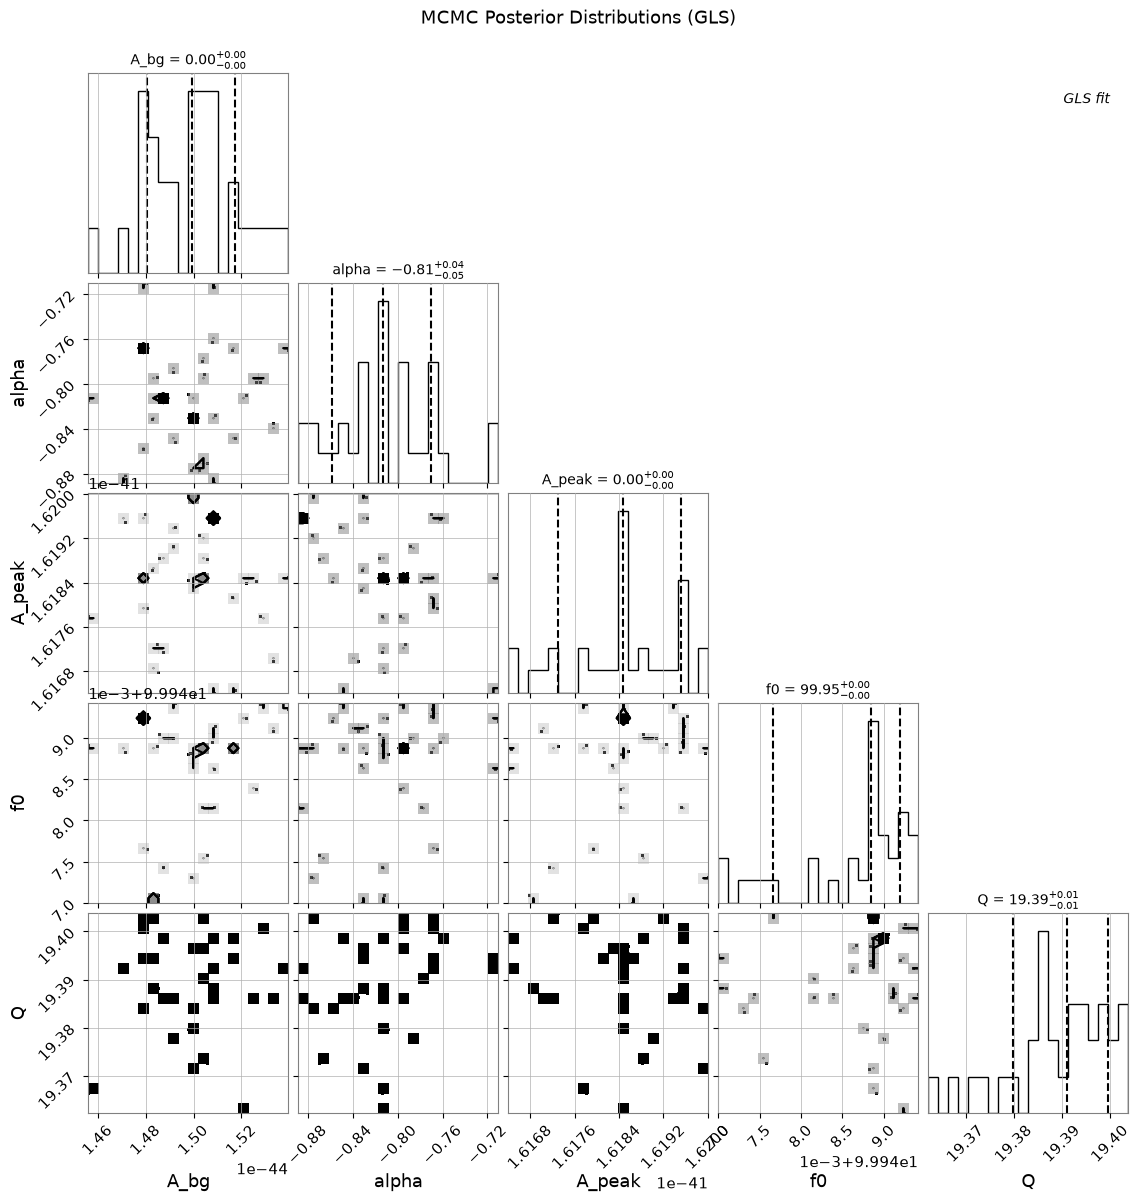

In [22]:
if mcmc_available:
    # Corner plot
    try:
        result_gls.plot_corner(
            truths=list(true_params.values()),
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True,
        )
        plt.suptitle("MCMC Posterior Distributions (GLS)", y=1.02)
        plt.show()
    except ImportError:
        print("Corner plot requires 'corner' package")

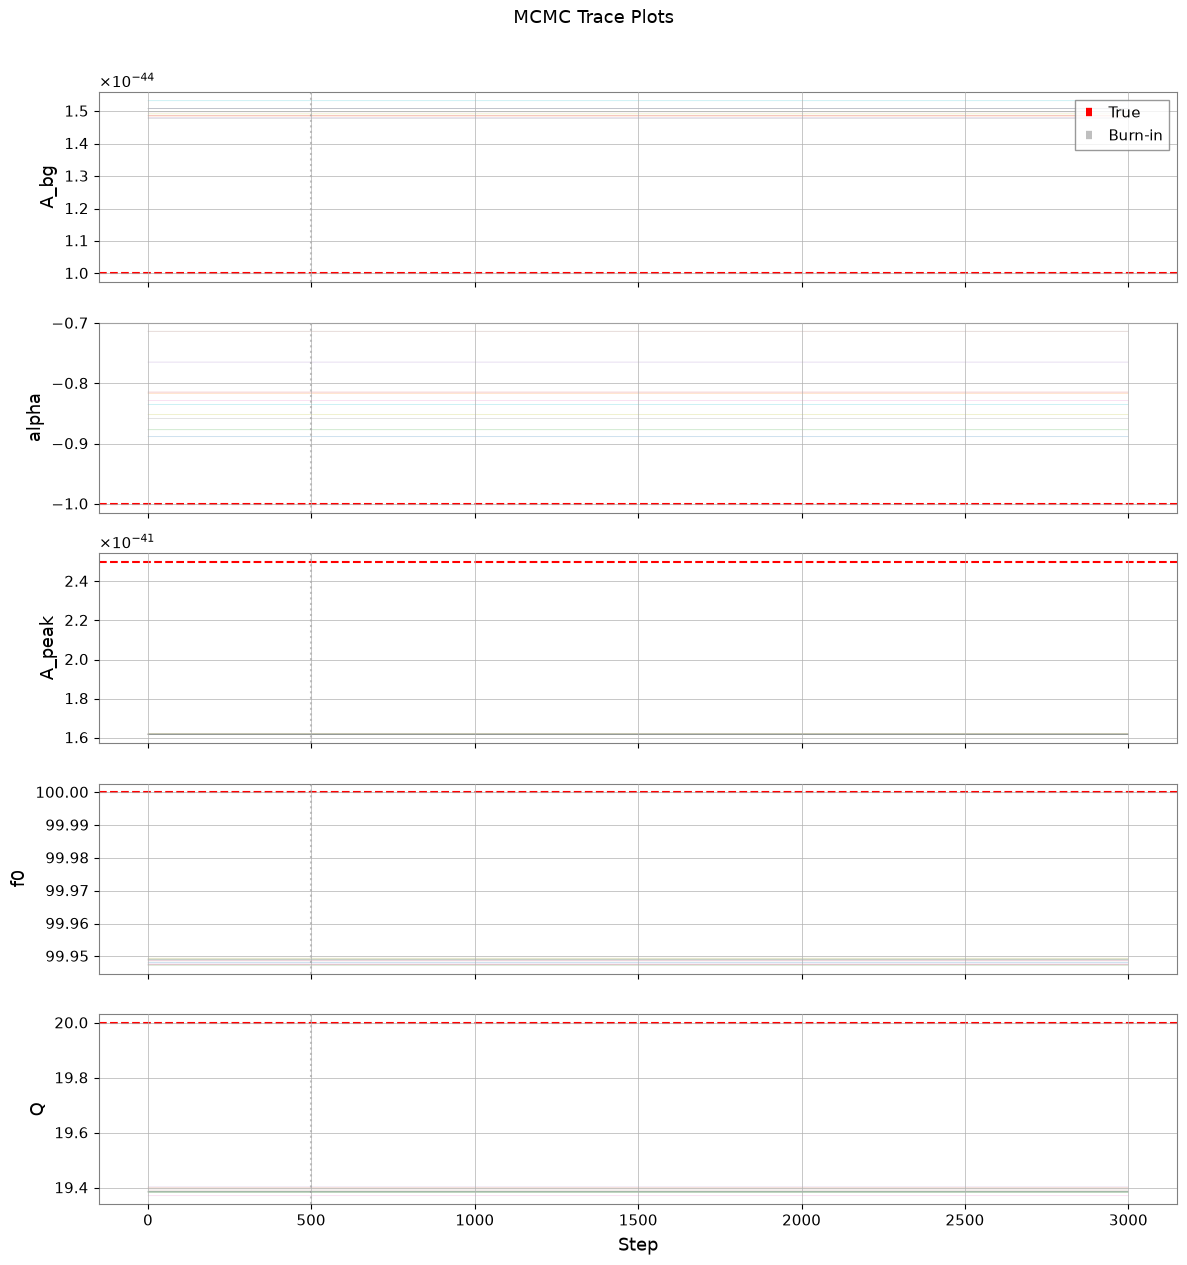

In [23]:
if mcmc_available:
    # Trace plots
    samples = sampler.get_chain()  # Shape: (n_steps, n_walkers, n_params)
    param_names = list(params_gls.keys())

    fig, axes = plt.subplots(len(param_names), 1, figsize=(12, 2.5 * len(param_names)), sharex=True)

    for i, (ax, name) in enumerate(zip(axes, param_names)):
        for j in range(min(10, n_walkers)):  # Plot subset of walkers
            ax.plot(samples[:, j, i], alpha=0.3, linewidth=0.5)
        ax.axhline(true_params[name], color="r", linestyle="--", label="True")
        ax.axvline(burn_in, color="gray", linestyle=":", alpha=0.5, label="Burn-in")
        ax.set_ylabel(name)
        if i == 0:
            ax.legend(loc="upper right")

    axes[-1].set_xlabel("Step")
    plt.suptitle("MCMC Trace Plots", y=1.01)
    plt.tight_layout()
    plt.show()

## 6. GLS vs OLS Comparison

### 6.1 Run OLS Fit (Diagonal Covariance Only)

OLS (Ordinary Least Squares) ignores off-diagonal correlations, using only the diagonal variances.

In [24]:
# Create diagonal-only covariance (for OLS)
diag_variances = np.diag(cov_fit.value)
cov_diag_matrix = np.diag(diag_variances)

cov_ols = BifrequencyMap.from_points(
    cov_diag_matrix,
    f2=cov_fit.frequency2,
    f1=cov_fit.frequency1,
    unit=cov_fit.unit,
    name="Diagonal Covariance (OLS)",
)

# OLS fit
result_ols = fit_series(
    psd_fit,
    psd_model,
    cov=cov_ols,
    p0=p0,
    limits=bounds,
)

print("OLS Fit Results:")
print("=" * 50)
display(result_ols)

OLS Fit Results:


### 6.2 Compare GLS and OLS Results

In [25]:
params_ols = result_ols.params
errors_ols = result_ols.errors

print("\nGLS vs OLS Comparison:")
print("=" * 85)
print(f"{'Parameter':<10} {'GLS Value':<14} {'GLS Error':<12} {'OLS Value':<14} {'OLS Error':<12} {'Ratio':>8}")
print("-" * 85)

error_ratios = []
for name in params_gls.keys():
    gls_val = params_gls[name]
    gls_err = errors_gls[name]
    ols_val = params_ols[name]
    ols_err = errors_ols[name]
    ratio = gls_err / ols_err if ols_err > 0 else float('inf')
    error_ratios.append((name, ratio))

    if abs(gls_val) < 0.01:
        print(f"{name:<10} {gls_val:<14.3e} {gls_err:<12.3e} {ols_val:<14.3e} {ols_err:<12.3e} {ratio:>8.2f}")
    else:
        print(f"{name:<10} {gls_val:<14.4f} {gls_err:<12.4f} {ols_val:<14.4f} {ols_err:<12.4f} {ratio:>8.2f}")

print("-" * 85)
print(f"\nχ²/ndof:  GLS = {result_gls.reduced_chi2:.3f}    OLS = {result_ols.reduced_chi2:.3f}")


GLS vs OLS Comparison:
Parameter  GLS Value      GLS Error    OLS Value      OLS Error       Ratio
-------------------------------------------------------------------------------------
A_bg       1.498e-44      2.212e-45    6.784e-45      9.760e-46        2.27
alpha      -0.8147        0.3731       -0.9548        0.2299           1.62
A_peak     1.619e-41      1.116e-43    1.693e-41      3.968e-43        0.28
f0         99.9485        0.0078       99.9719        0.0292           0.27
Q          19.3873        0.0943       19.8040        0.2719           0.35
-------------------------------------------------------------------------------------

χ²/ndof:  GLS = 3.167    OLS = 0.620


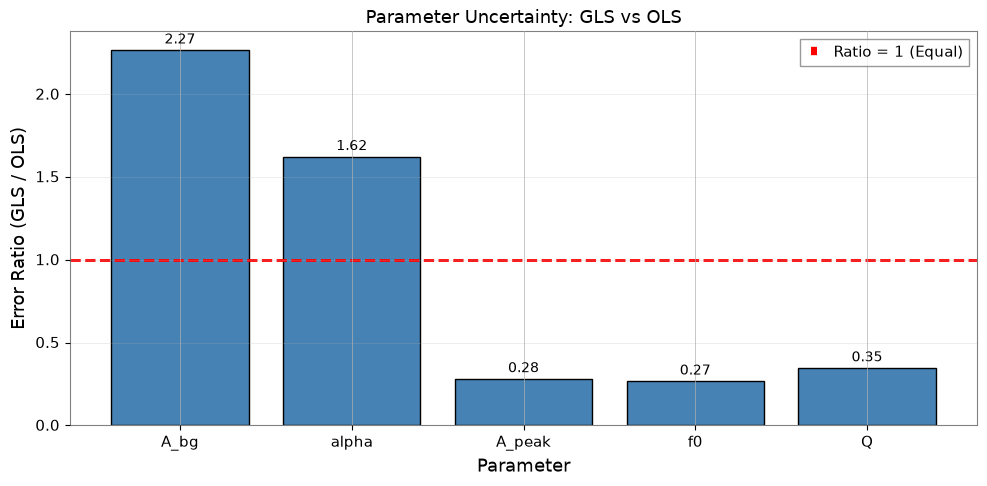

In [26]:
# Visualize error ratio comparison
fig, ax = plt.subplots(figsize=(10, 5))

names = [r[0] for r in error_ratios]
ratios = [r[1] for r in error_ratios]

x = np.arange(len(names))
bars = ax.bar(x, ratios, color="steelblue", edgecolor="black")

# Add reference line at ratio=1
ax.axhline(1.0, color="r", linestyle="--", linewidth=2, label="Ratio = 1 (Equal)")

ax.set_xlabel("Parameter")
ax.set_ylabel("Error Ratio (GLS / OLS)")
ax.set_title("Parameter Uncertainty: GLS vs OLS")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Annotate bars
for bar, ratio in zip(bars, ratios):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{ratio:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

### 6.3 Key Insights

**GLS errors are typically larger than OLS errors** because:

1. **OLS underestimates uncertainties** by ignoring positive correlations between adjacent bins
2. **GLS properly accounts** for the reduced effective degrees of freedom
3. The error ratio (GLS/OLS > 1) reflects the **true impact of correlations**

**Expected with ~0.25 correlation**: GLS errors 10-30% larger than OLS

**Why GLS differs from OLS**:
1. OLS assumes independence → underestimates uncertainties
2. GLS accounts for correlation → reduces effective degrees of freedom
3. Error ratio (GLS/OLS) quantifies correlation impact
4. With 50% overlap: ~0.25 correlation leads to meaningful GLS vs OLS differences

**Practical implications:**
- OLS may produce overconfident (too small) error bars
- GLS provides more honest uncertainty estimates
- For precision measurements, GLS is essential


## 7. Summary and Best Practices

### Key Takeaways

1. **Bootstrap PSD estimation** provides both the spectrum and its full covariance matrix
2. **Overlapping segments** introduce correlations that standard methods ignore
3. **GLS fitting** properly weights data according to the covariance structure
4. **MCMC** provides robust posterior distributions for complex models
5. **OLS underestimates errors** when correlations are present

### Recommended Workflow

```python
# 1. Generate spectrogram
stride = fftlength - overlap
spectrogram = data.spectrogram(stride=stride, fftlength=fftlength, overlap=overlap, window='hann')

# 2. Bootstrap with covariance
psd, cov = bootstrap_spectrogram(spectrogram, return_map=True, ...)

# 3. GLS fit
result = fit_series(psd, model, cov=cov, p0=..., limits=...)

# 4. MCMC for robust uncertainties
result.run_mcmc(n_walkers=32, n_steps=5000)
result.plot_corner()
```

### Common Pitfalls

- **Using OLS for correlated data** → underestimated errors
- **Too few bootstrap samples** → noisy covariance estimate
- **Poor initial guesses** → fit may converge to local minimum
- **Forgetting to crop covariance** → dimension mismatch errors

## Appendix: BifrequencyMap Operations

Quick reference for common `BifrequencyMap` operations.

In [27]:
# Example BifrequencyMap operations

# 1. Get inverse (for manual GLS)
cov_inv = cov_fit.inverse()
print(f"Inverse shape: {cov_inv.shape}")
print(f"Inverse unit: {cov_inv.unit}")

# 2. Extract diagonal (variances)
variances = np.diag(cov_fit.value)
std_devs = np.sqrt(np.maximum(variances, 0))
print(f"\nDiagonal extracted: {len(variances)} values")

# 3. Compute correlation matrix
std_outer = np.outer(std_devs, std_devs)
std_outer[std_outer == 0] = 1
correlation = cov_fit.value / std_outer
print(f"Correlation range: [{correlation.min():.3f}, {correlation.max():.3f}]")

# 4. Create from scratch
n = 10
test_cov = np.eye(n) + 0.1 * np.ones((n, n))  # Diagonal + small off-diagonal
test_freqs = np.arange(n) * 1.0 + 50.0
test_map = BifrequencyMap.from_points(
    test_cov,
    f2=test_freqs,
    f1=test_freqs,
    unit="Hz^-2",
    name="Test Covariance",
)
print(f"\nCreated test BifrequencyMap: {test_map.shape}")

Inverse shape: (720, 720)
Inverse unit: Hz2

Diagonal extracted: 720 values
Correlation range: [-0.400, 1.000]

Created test BifrequencyMap: (10, 10)


---

## Further Reading

- **Percival & Walden (1993)**: Spectral Analysis for Physical Applications - VIF derivation
- **gwexpy API**: [Spectral module](../../reference/api/spectral.rst), [Fitting module](../../reference/api/fitting.rst)
- **Related theory**: [Validated Algorithms](../validated_algorithms.md), [Numerical Stability](../numerical_stability.md)
- **Related tutorials**: [Advanced Fitting](advanced_fitting.ipynb), [Noise Budget](case_noise_budget.ipynb)